In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv(r"C:/SpaceMission/data/space_missions_dataset.csv")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Mission ID                         500 non-null    object 
 1   Mission Name                       500 non-null    object 
 2   Launch Date                        500 non-null    object 
 3   Target Type                        500 non-null    object 
 4   Target Name                        500 non-null    object 
 5   Mission Type                       500 non-null    object 
 6   Distance from Earth (light-years)  500 non-null    float64
 7   Mission Duration (years)           500 non-null    float64
 8   Mission Cost (billion USD)         500 non-null    float64
 9   Scientific Yield (points)          500 non-null    float64
 10  Crew Size                          500 non-null    int64  
 11  Mission Success (%)                500 non-null    float64

In [12]:
df["Launch Date"]=pd.to_datetime(df["Launch Date"],errors="coerce")
df["Launch Date"].dtype


dtype('<M8[ns]')

In [13]:
df.head()

,Mission ID,Mission Name,Launch Date,Target Type,Target Name,Mission Type,Distance from Earth (light-years),Mission Duration (years),Mission Cost (billion USD),Scientific Yield (points),Crew Size,Mission Success (%),Fuel Consumption (tons),Payload Weight (tons),Launch Vehicle
0,MSN-0001,Mission-1,2025-01-01,Star,Titan,Colonization,7.05,5.2,526.68,64.3,21,100.0,731.88,99.78,SLS
1,MSN-0002,Mission-2,2025-01-08,Exoplanet,Betelgeuse,Colonization,41.76,23.0,234.08,84.4,72,89.6,4197.41,45.72,Starship
2,MSN-0003,Mission-3,2025-01-15,Asteroid,Mars,Exploration,49.22,28.8,218.68,98.6,16,98.6,4908.00,36.12,Starship
3,MSN-0004,Mission-4,2025-01-22,Exoplanet,Titan,Colonization,26.33,17.8,232.89,36.0,59,90.0,2569.05,40.67,Starship
4,MSN-0005,Mission-5,2025-01-29,Exoplanet,Proxima b,Mining,8.67,9.2,72.14,96.5,31,73.2,892.76,12.40,Starship


In [20]:
df["Mission Success (%)"].describe()

count    500.000000
mean      92.616600
std        9.391094
min       66.000000
25%       85.500000
50%       98.600000
75%      100.000000
max      100.000000
Name: Mission Success (%), dtype: float64

In [ ]:
# Q1.Which mission type (Exploration, Mining, Research, Colonization) has the highest average mission success rate? 
Highest_Success=df[df["Mission Success (%)"]>92.62] [["Mission Name","Mission Success (%)"]]
Highest_Success


,Mission Name,Mission Success (%)
0,Mission-1,100.0
2,Mission-3,98.6
5,Mission-6,100.0
6,Mission-7,95.5
8,Mission-9,100.0
...,...,...
495,Mission-496,96.2
496,Mission-497,100.0
497,Mission-498,100.0
498,Mission-499,100.0


In [29]:
# Q1.Which mission type (Exploration, Mining, Research, Colonization) has the highest average mission success rate? 
avg_success=df.groupby("Mission Type")["Mission Success (%)"].mean().sort_values(ascending=False)
avg_success.round(2)

Mission Type
Mining          93.51
Exploration     92.89
Colonization    92.53
Research        91.65
Name: Mission Success (%), dtype: float64

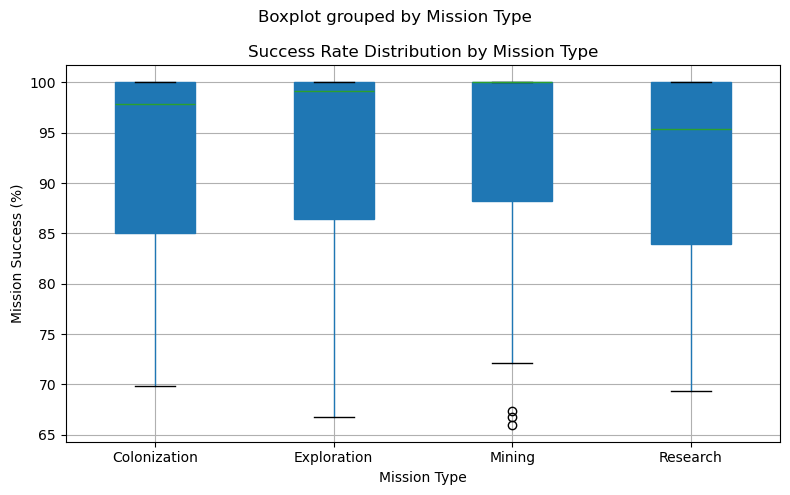

In [36]:
df.boxplot(column="Mission Success (%)", by="Mission Type", figsize=(8, 5), 
           patch_artist=True)
#plt.suptitle("")
plt.title("Success Rate Distribution by Mission Type", fontsize=12)
plt.xlabel("Mission Type")
plt.ylabel("Mission Success (%)")
plt.tight_layout()
plt.show()

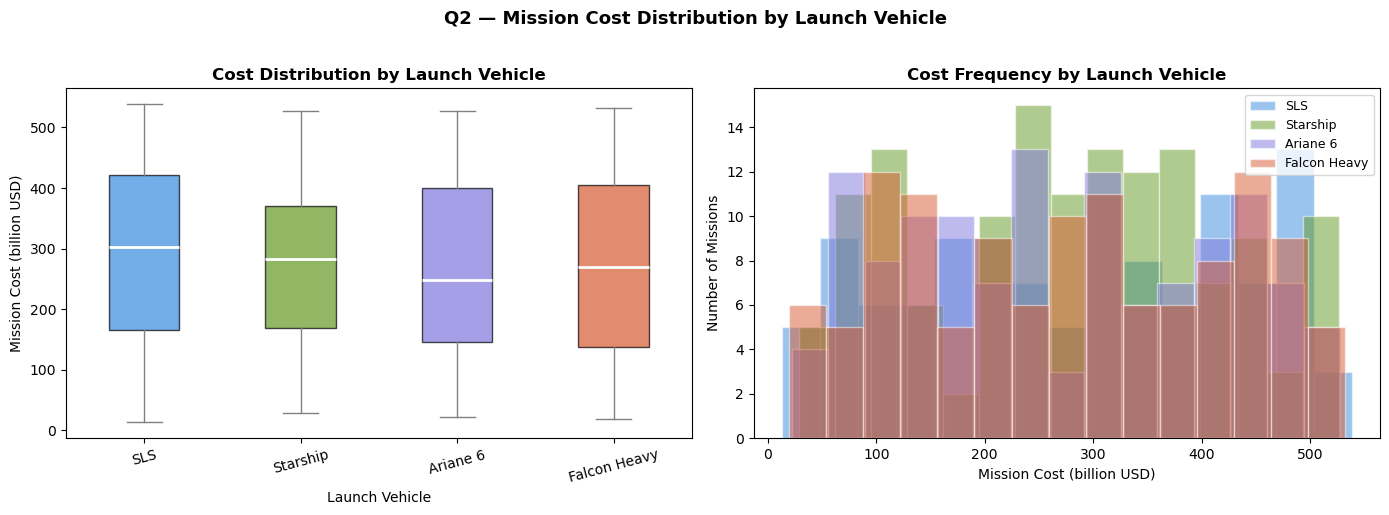

In [73]:
# Q2.How does the distribution of mission cost vary across different launch vehicles (SLS, Starship, Ariane 6, Falcon Heavy)?
Mission_Cost=df.groupby("Launch Vehicle")["Mission Cost (billion USD)"].describe().round(2)#.sort_values(ascending=False)
Mission_Cost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vehicles = df["Launch Vehicle"].unique()
colors   = ["#378ADD", "#639922", "#7F77DD", "#D85A30"]

# --- Plot 1: Boxplot ---
cost_data = [df[df["Launch Vehicle"] == v]["Mission Cost (billion USD)"].values
             for v in vehicles]

bp = axes[0].boxplot(cost_data, labels=vehicles, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for whisker in bp["whiskers"]: whisker.set_color("gray")
for cap     in bp["caps"]    : cap.set_color("gray")
for flier   in bp["fliers"]  : flier.set(marker="o", alpha=0.4)

axes[0].set_title("Cost Distribution by Launch Vehicle", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Launch Vehicle", fontsize=10)
axes[0].set_ylabel("Mission Cost (billion USD)", fontsize=10)
axes[0].tick_params(axis="x", rotation=15)

# --- Plot 2: Histogram ---
for i, v in enumerate(vehicles):
    subset = df[df["Launch Vehicle"] == v]["Mission Cost (billion USD)"]
    axes[1].hist(subset, bins=15, alpha=0.5, label=v,
                 color=colors[i], edgecolor="white")

axes[1].set_title("Cost Frequency by Launch Vehicle", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mission Cost (billion USD)", fontsize=10)
axes[1].set_ylabel("Number of Missions", fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle("Q2 — Mission Cost Distribution by Launch Vehicle",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

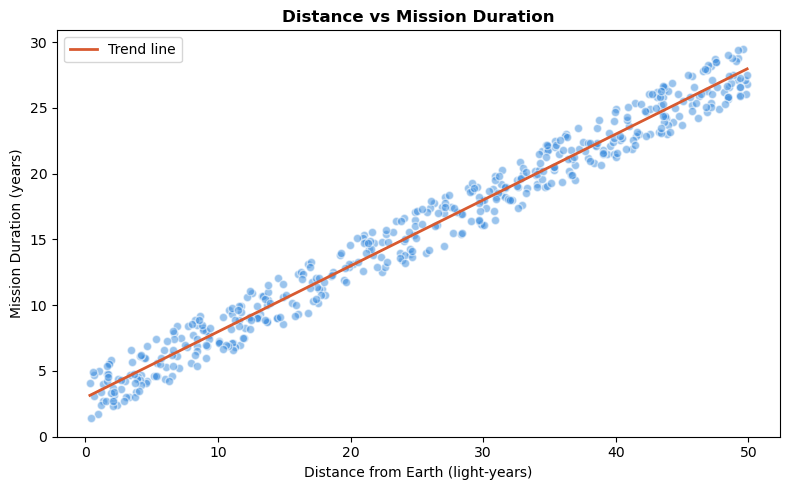

,Distance from Earth (light-years),Mission Duration (years)
0,7.05,5.2
1,41.76,23.0
2,49.22,28.8
3,26.33,17.8
4,8.67,9.2
...,...,...
495,48.26,25.3
496,0.35,4.1
497,47.60,26.6
498,31.99,18.0


In [65]:
#Q3.What is the relationship between distance from Earth and mission duration? Does farther always mean longer?
DD=df[["Distance from Earth (light-years)","Mission Duration (years)"]]#.sort_values(ascending=False)

DD.corr().round(2)
plt.figure(figsize=(8, 5))
plt.scatter(DD["Distance from Earth (light-years)"],
            DD["Mission Duration (years)"],
            alpha=0.5, color="#378ADD", edgecolors="white")

# Trend line
m, b = np.polyfit(DD["Distance from Earth (light-years)"], DD["Mission Duration (years)"], 1)
x = np.linspace(DD["Distance from Earth (light-years)"].min(),
                DD["Distance from Earth (light-years)"].max(), 100)
plt.plot(x, m*x + b, color="#D85A30", linewidth=2, label="Trend line")

plt.title("Distance vs Mission Duration", fontsize=12, fontweight="bold")
plt.xlabel("Distance from Earth (light-years)")
plt.ylabel("Mission Duration (years)")
plt.legend()
plt.tight_layout()
plt.show()
DD

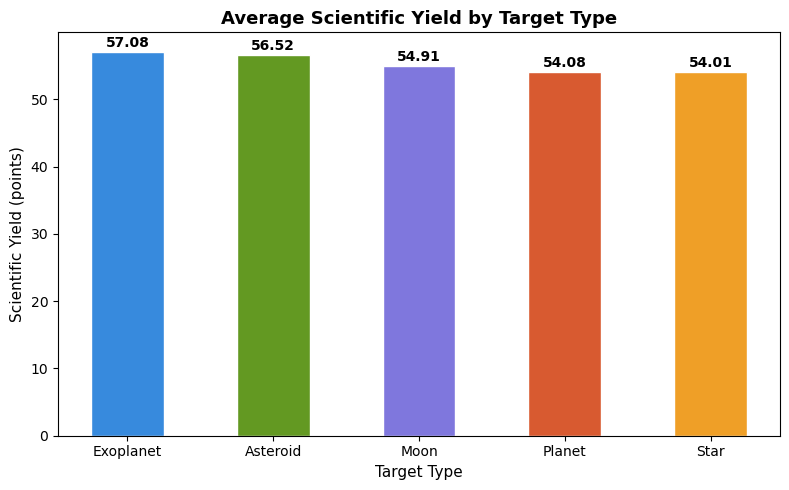

In [ ]:
#Q4.Which target type (Star, Exoplanet, Asteroid, Moon, Planet) yields the highest scientific yield on average?
Highest_Yield=df.groupby("Target Type")["Scientific Yield (points)"].mean().round(2).sort_values(ascending=False)
Highest_Yield
plt.figure(figsize=(8, 5))
bars = plt.bar(Highest_Yield.index, Highest_Yield.values,
               color=["#378ADD","#639922","#7F77DD","#D85A30","#EF9F27"],
               edgecolor="white", width=0.5)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{bar.get_height():.2f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Average Scientific Yield by Target Type", fontsize=13, fontweight="bold")
plt.xlabel("Target Type", fontsize=11)
plt.ylabel("Scientific Yield (points)", fontsize=11)
plt.tight_layout()
plt.show()

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Mission ID                         500 non-null    object        
 1   Mission Name                       500 non-null    object        
 2   Launch Date                        500 non-null    datetime64[ns]
 3   Target Type                        500 non-null    object        
 4   Target Name                        500 non-null    object        
 5   Mission Type                       500 non-null    object        
 6   Distance from Earth (light-years)  500 non-null    float64       
 7   Mission Duration (years)           500 non-null    float64       
 8   Mission Cost (billion USD)         500 non-null    float64       
 9   Scientific Yield (points)          500 non-null    float64       
 10  Crew Size                          500

Full Success Missions: 233
Partial Success Missions: 267
Full Success Mean Cost: 401.01
Partial Success Mean Cost: 169.35
T-statistic : 31.9255
P-value     : 0.0000

Result: Statistically SIGNIFICANT difference. 
→ Mission cost IS meaningfully different between successful and partial missions.


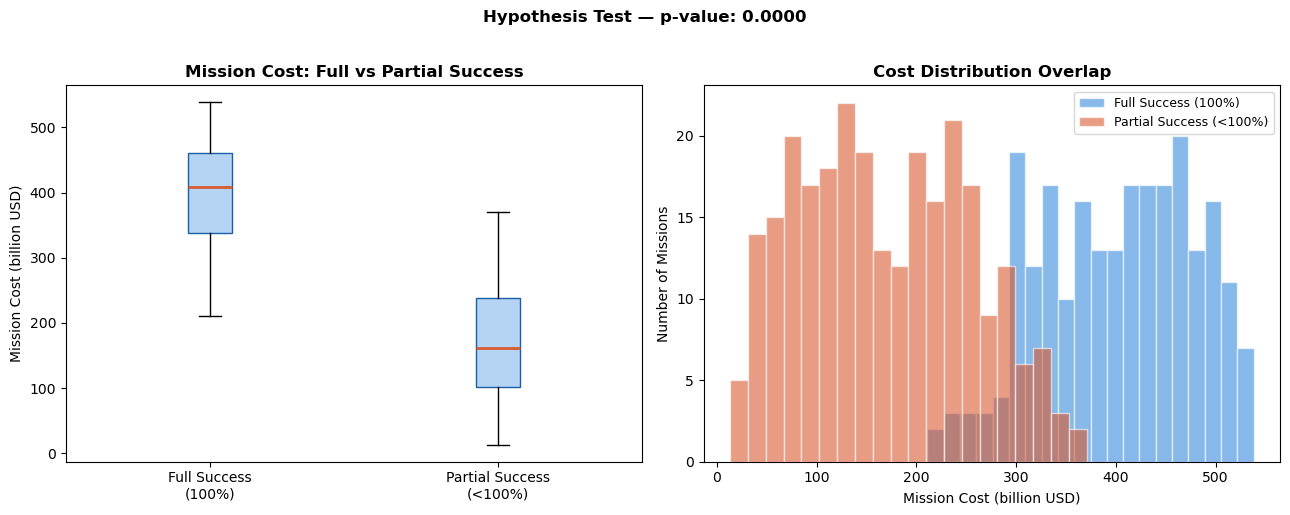

In [93]:
#Q5.Is there a statistically significant difference in mission cost between successful (100%) and partially successful missions? Run a hypothesis test.
FUll_Success=df[df["Mission Success (%)"]==100]["Mission Cost (billion USD)"]
Partial_Success=df[df["Mission Success (%)"]<100]["Mission Cost (billion USD)"]
print("Full Success Missions:",len(FUll_Success))
print("Partial Success Missions:",len(Partial_Success))
print("Full Success Mean Cost:",FUll_Success.mean().round(2))
print("Partial Success Mean Cost:",Partial_Success.mean().round(2))
from scipy import stats

t_stat, p_value = stats.ttest_ind(FUll_Success, Partial_Success)

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: Statistically SIGNIFICANT difference. ")
    print("→ Mission cost IS meaningfully different between successful and partial missions.")
else:
    print("Result: No statistically significant difference.")
    print("→ Cost difference between the two groups is likely due to random chance.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Boxplot ---
axes[0].boxplot([FUll_Success,Partial_Success],
                labels=["Full Success\n(100%)", "Partial Success\n(<100%)"],
                patch_artist=True,
                boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
                medianprops=dict(color="#D85A30", linewidth=2),
                flierprops=dict(marker="o", color="#D85A30", alpha=0.4))
axes[0].set_title("Mission Cost: Full vs Partial Success",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Mission Cost (billion USD)", fontsize=10)

# --- Histogram ---
axes[1].hist(FUll_Success,    bins=20, alpha=0.6, color="#378ADD",
             label="Full Success (100%)",  edgecolor="white")
axes[1].hist(Partial_Success, bins=20, alpha=0.6, color="#D85A30",
             label="Partial Success (<100%)", edgecolor="white")
axes[1].set_title("Cost Distribution Overlap",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mission Cost (billion USD)", fontsize=10)
axes[1].set_ylabel("Number of Missions", fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle(f"Hypothesis Test — p-value: {p_value:.4f}",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()